# Chapter 51 — From Physics to Features: Preparing Strain Data for Learning
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 51 — From Physics to Features: Preparing Strain Data for Learning.

*The strain gage gives us the signal; feature engineering determines whether we understand it.*

A strain signal is a sequence of numbers, but it is not a set of *features*. A machine learning model cannot reason about "the signal looks like it has a crack" — it needs numbers that represent that observation. *Feature extraction* is the process of transforming raw time-series data into a compact vector of meaningful quantities that a model can use as inputs. Some features come directly from signal processing: RMS, peak-to-peak amplitude, kurtosis, dominant frequency, spectral centroid. Others come from domain knowledge about how structural damage manifests in strain signals.

The key insight is that not all features are equally informative for health monitoring. Mean strain tells you almost nothing about structural condition — a damaged structure at the same load produces nearly the same mean as a healthy one. But standard deviation, kurtosis, and spectral content change substantially with damage. The simulated comparison below quantifies this: mean shifts by 0.0%, while standard deviation shifts by 20.6% and peak-to-peak by 35.3%. A frequency shift in the dominant mode — from 42 Hz to 38 Hz — indicates a change in structural stiffness. A new high-frequency component at 210 Hz appears only in the damaged signal, consistent with a fatigue crack introducing impulsive contact.

*Feature selection* is the act of deciding which of these extracted quantities to include in the model. Including all features without selection risks overfitting on noise. But excluding important features — like the 210 Hz component above — means the model cannot see the damage at all. The physics of the failure mechanism should guide which features are computed.

**This notebook demonstrates:**
1. Statistical and spectral feature extraction from simulated healthy and damaged strain signals — with time-domain and FFT comparisons showing how damage shifts each feature.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Save figures next to the chapter sources so the book can \includegraphics them directly.
OUT_DIR = Path("../src/media/ch51")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Statistical and Spectral Features: Healthy vs. Damaged Signals

Two signals are simulated: a healthy structure responding at 42 Hz and 87 Hz, and a damaged structure where the fundamental has shifted to 38 Hz (stiffness reduction), a new 210 Hz component has appeared (crack-induced impulsive contact), and the noise floor has increased from σ = 8 με to σ = 12 με. Both signals are sampled at 2000 Hz for 5 seconds.

The feature table quantifies what these differences look like in numbers. Mean strain is essentially unchanged (Δ = 0.0%), confirming it is useless for health monitoring. Standard deviation increases by 20.6% and peak-to-peak by 35.3% — both sensitive to the increased variability from the new frequency component. Kurtosis increases by 21.8%, reflecting the impulsive character of the crack contact event, which produces occasional large spikes above the background vibration. Dominant frequency shifts from 42 Hz to 38 Hz.

The time-domain and FFT plots that follow make these numbers visual. In the time-domain window, the damaged signal is visibly noisier and has a slightly different envelope. In the FFT, the 210 Hz component appears clearly in the damaged signal and is absent from the healthy one — a signature that a trained classifier can detect with high reliability.

In [2]:
# Reproducible synthetic strain records: one "healthy" structure, one "damaged".
# Seeding fixes the noise draw so the feature table below is identical on every run
# (the chapter quotes these exact percentages).
SEED = 5

FS_HZ = 2000.0           # sample rate
DURATION_S = 5.0         # record length
DC_OFFSET_UE = 200.0     # static bias strain (με)

# Modal content shared by both structures
F2_HZ = 87.0             # second structural mode (unaffected by the damage)
A1_UE = 50.0             # amplitude of the fundamental mode (με)
A2_UE = 20.0             # amplitude of the second mode (με)

# Healthy structure
F1_HEALTHY_HZ = 42.0     # fundamental mode
NOISE_HEALTHY_UE = 8.0   # measurement noise, std (με)

# Damaged structure: softened fundamental, new crack mode, higher noise floor
F1_DAMAGED_HZ = 38.0     # fundamental drops as stiffness is lost
F_CRACK_HZ = 210.0       # crack-induced impulsive / high-frequency content
A_CRACK_UE = 35.0        # amplitude of the crack mode (με)
NOISE_DAMAGED_UE = 12.0  # elevated noise floor, std (με)

np.random.seed(SEED)
t = np.arange(0, DURATION_S, 1 / FS_HZ)

sig_healthy = (DC_OFFSET_UE
               + A1_UE * np.sin(2 * np.pi * F1_HEALTHY_HZ * t)
               + A2_UE * np.sin(2 * np.pi * F2_HZ * t)
               + np.random.normal(0, NOISE_HEALTHY_UE, len(t)))
sig_damaged = (DC_OFFSET_UE
               + A1_UE * np.sin(2 * np.pi * F1_DAMAGED_HZ * t)
               + A2_UE * np.sin(2 * np.pi * F2_HZ * t)
               + A_CRACK_UE * np.sin(2 * np.pi * F_CRACK_HZ * t)   # new high-freq (crack) mode
               + np.random.normal(0, NOISE_DAMAGED_UE, len(t)))


def features(sig, fs):
    """Extract a compact feature vector from a 1-D strain signal.

    Returns a dict of eight time- and frequency-domain features. The spectral
    features use the single-sided FFT amplitude of the mean-removed signal, so
    the DC bias does not dominate the dominant-frequency and centroid estimates.

    Parameters
    ----------
    sig : np.ndarray
        Strain samples in microstrain (με).
    fs : float
        Sample rate in Hz.
    """
    N = len(sig)
    S = np.abs(fft(sig - sig.mean())[:N // 2]) * 2 / N    # single-sided amplitude
    freqs = fftfreq(N, 1 / fs)[:N // 2]
    return {
        'mean (με)':      sig.mean(),
        'RMS (με)':       np.sqrt(np.mean(sig**2)),
        'std (με)':       sig.std(),
        'peak-peak (με)': sig.max() - sig.min(),
        'kurtosis':       np.mean((sig - sig.mean())**4) / sig.std()**4,
        'crest factor':   sig.max() / np.sqrt(np.mean(sig**2)),
        'dom. freq (Hz)': freqs[np.argmax(S)],
        'spectral centroid (Hz)': np.sum(freqs * S) / np.sum(S),
    }


fh = features(sig_healthy, FS_HZ)
fd = features(sig_damaged, FS_HZ)
print(f"{'Feature':25s}  {'Healthy':>12}  {'Damaged':>12}  {'Change (%)':>12}")
print("-" * 65)
for k in fh:
    pct = 100 * (fd[k] - fh[k]) / abs(fh[k]) if fh[k] != 0 else float('nan')
    print(f"{k:25s}  {fh[k]:>12.3f}  {fd[k]:>12.3f}  {pct:>12.1f}")

Feature                         Healthy       Damaged    Change (%)
-----------------------------------------------------------------
mean (με)                       199.998       200.042           0.0
RMS (με)                        203.746       205.470           0.8
std (με)                         38.904        46.914          20.6
peak-peak (με)                  181.023       244.879          35.3
kurtosis                          1.958         2.385          21.8
crest factor                      1.410         1.572          11.4
dom. freq (Hz)                   42.000        38.000          -9.5
spectral centroid (Hz)          458.793       465.422           1.4


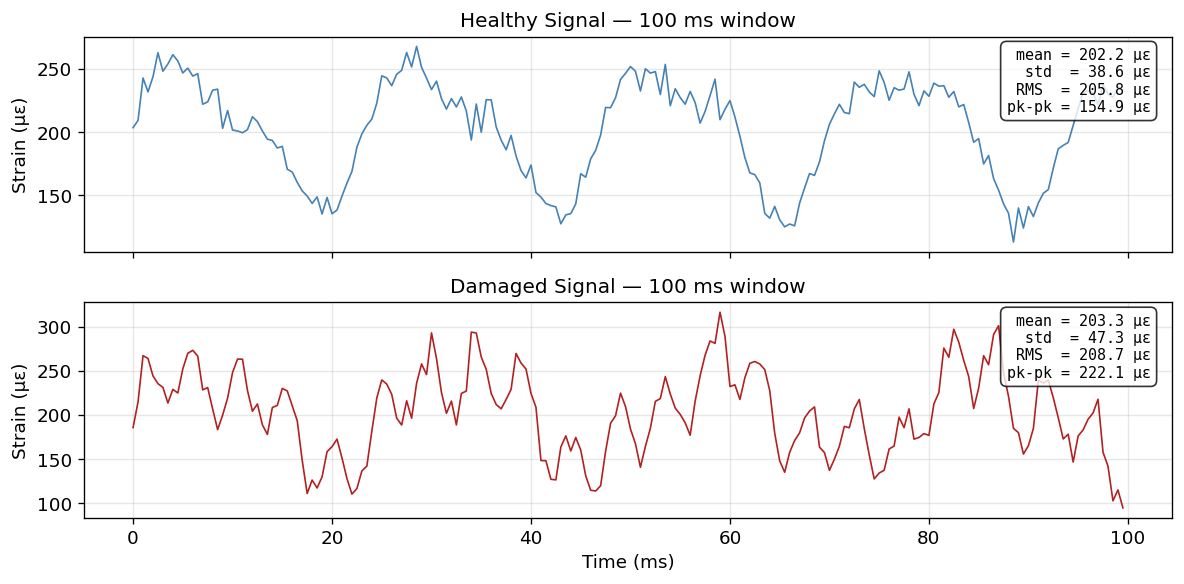

In [3]:
# --- Time-domain plot with summary statistics (first WINDOW_MS of each record) ---
WINDOW_MS = 100
window = slice(0, int(WINDOW_MS / 1000 * FS_HZ))


def stat_label(sig):
    """Format a window's four time-domain summary features as a text block."""
    return (f"mean = {sig.mean():.1f} με\n"
            f"std  = {sig.std():.1f} με\n"
            f"RMS  = {np.sqrt(np.mean(sig**2)):.1f} με\n"
            f"pk-pk = {sig.max() - sig.min():.1f} με")


fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for ax, sig, label, color in [
    (axes[0], sig_healthy, 'Healthy Signal', 'steelblue'),
    (axes[1], sig_damaged, 'Damaged Signal', 'firebrick'),
]:
    ax.plot(t[window] * 1000, sig[window], color=color, lw=1.0)
    ax.set_ylabel('Strain (με)')
    ax.set_title(f'{label} — {WINDOW_MS} ms window')
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.95, stat_label(sig[window]),
            transform=ax.transAxes, fontsize=9, va='top', ha='right',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

axes[1].set_xlabel('Time (ms)')
fig.tight_layout()
plt.savefig(OUT_DIR / 'fig51_nb1_strain_signal_healthy_damaged.png', bbox_inches='tight', dpi=150)
plt.show()

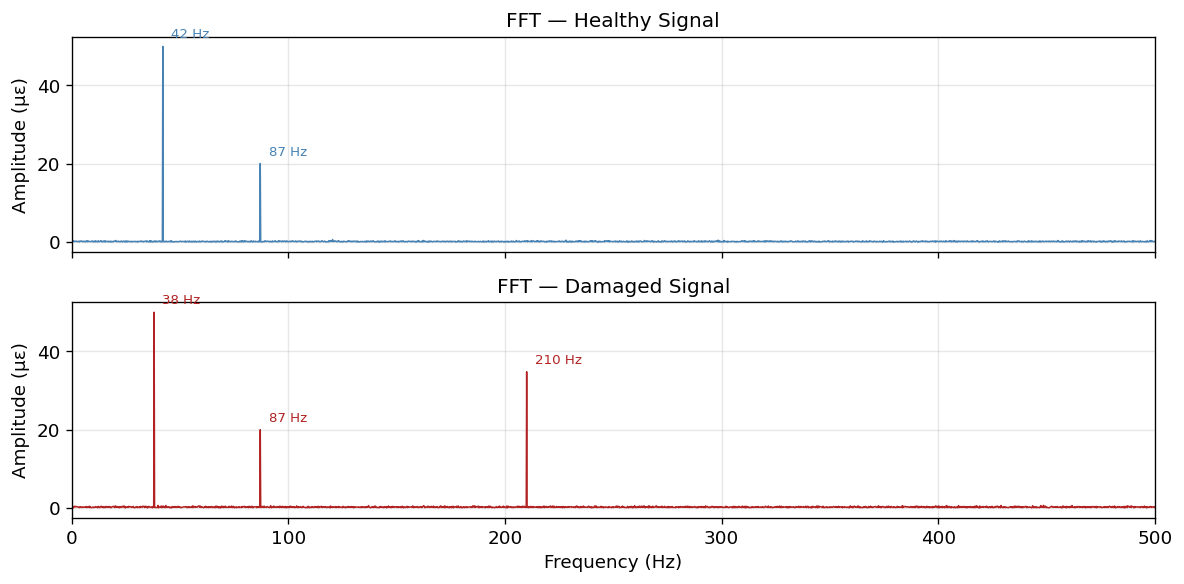

In [4]:
# --- FFT of both signals over the full record ---
def compute_fft(sig, fs):
    """Return (freqs, amplitude) of the single-sided FFT of a mean-removed signal.

    Removing the mean suppresses the DC bin so the structural and crack modes
    dominate the spectrum. Amplitudes are scaled by 2/N to read in microstrain.
    """
    N = len(sig)
    S = np.abs(fft(sig - sig.mean())[:N // 2]) * 2 / N
    freqs = fftfreq(N, 1 / fs)[:N // 2]
    return freqs, S


freqs_h, S_h = compute_fft(sig_healthy, FS_HZ)
freqs_d, S_d = compute_fft(sig_damaged, FS_HZ)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for ax, freqs, S, label, color in [
    (axes[0], freqs_h, S_h, 'Healthy Signal', 'steelblue'),
    (axes[1], freqs_d, S_d, 'Damaged Signal', 'firebrick'),
]:
    ax.plot(freqs, S, color=color, lw=0.9)
    ax.set_ylabel('Amplitude (με)')
    ax.set_title(f'FFT — {label}')
    ax.grid(True, alpha=0.3)
    # annotate the four largest peaks above a small amplitude threshold
    peaks = np.argsort(S)[-4:][::-1]
    for p in peaks:
        if S[p] > 1.0:
            ax.annotate(f'{freqs[p]:.0f} Hz',
                        xy=(freqs[p], S[p]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=8, color=color)

axes[1].set_xlabel('Frequency (Hz)')
axes[0].set_xlim(0, 500)
fig.tight_layout()
plt.savefig(OUT_DIR / 'fig51_nb2_strain_fft_damage.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Where to take this next

This notebook stops at time- and frequency-domain features on a single channel. Three concrete extensions build directly on it:

1. **Add cycle-based features.** Run a rainflow count (with `rainflow` or `fatpack`) on each record, bin the cycles by amplitude, and accumulate Palmgren–Miner damage $D = \sum_i n_i / N_i$ (Chapter 51, Eq. 51.4) against an S-N curve. Compare $D$ for the healthy and damaged signals — a fatigue feature the FFT alone cannot see.

2. **Sweep damage severity.** Turn the two fixed scenarios into a parameter sweep: vary the softened fundamental (`F1_DAMAGED_HZ`) and the crack amplitude (`A_CRACK_UE`) across a range, recompute the feature table for each, and plot every feature's percent change versus severity. The result is a *feature-sensitivity curve* that reveals which features respond earliest and most linearly to damage.

3. **Train a leakage-safe classifier.** Generate many windowed records per class, extract the feature vector for each, then fit a simple model (`LogisticRegression` or `RandomForestClassifier`, with `random_state=0`) on a train/test split that keeps windows from the same record on the same side of the split — avoiding the leakage the chapter warns about. Report accuracy and feature importances; this is the natural bridge into the model-selection questions of Chapter 52.